In [1]:
from jax import config
config.update("jax_enable_x64", True)
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
import pyvista as pv
import nest_asyncio

nest_asyncio.apply()

pv.set_jupyter_backend('trame')

from pyvista.trame.jupyter import launch_server
await launch_server().ready

from Suspension.hardpoint_loader import load_suspension_params
from Suspension.jax_solvers import solve_and_measure_corner
from Suspension.visualizer import SuspensionVisualizer
from Suspension.jax_solvers import get_world_params
from Suspension.jax_solvers import solve_theta_for_ground

0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0


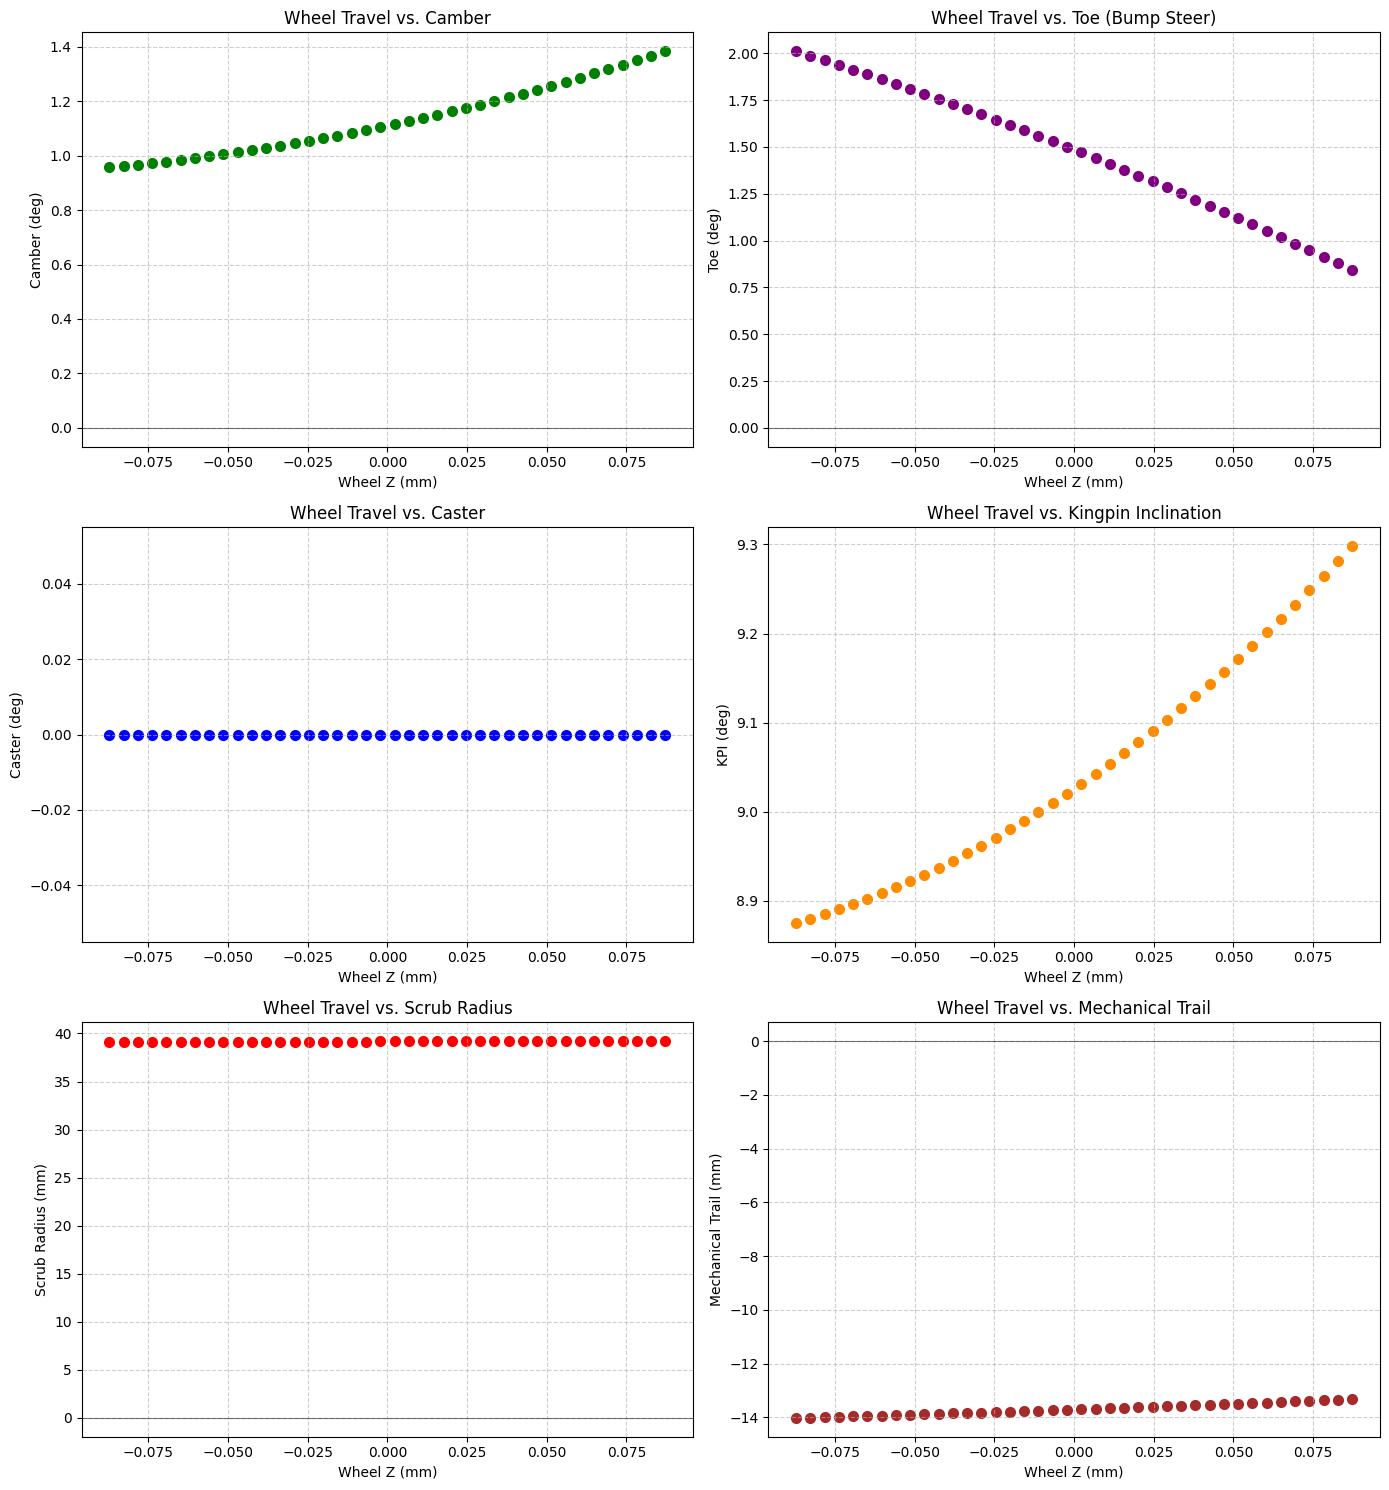

In [ ]:
# 1. Setup Parameters
corner_name = "front_right"
params = load_suspension_params("hardpoints.yaml", corner_name)

# 2. Define the Range of Motion
thetas = jnp.radians(jnp.linspace(-5.0, 5.0, 40)) 
fixed_steer = 0.0

# 3. Initialize storage for results
travel_mm = []
caster_deg = []
scrub_mm = []
camber_deg = []
toe_deg = []
kpi_deg = []    
mech_trail_mm = [] 

# 4. Run the Sweep Loop
for t in thetas:
    metrics = solve_and_measure_corner(t, fixed_steer, params)
    
    # Store the values (converting to readable units)
    travel_mm.append(metrics["wheel_z"] * 1000)
    caster_deg.append(jnp.degrees(metrics["caster"]))
    scrub_mm.append(metrics["scrub_radius"] * 1000)
    camber_deg.append(jnp.degrees(metrics["camber"]))
    toe_deg.append(jnp.degrees(metrics["toe"]))
    kpi_deg.append(jnp.degrees(metrics["kingpin_inc"]))
    mech_trail_mm.append(metrics["mechanical_trail"] * 1000)
    # print(metrics["caster"])

# 5. Plotting (Expanded to 3x2 Grid)
plt.figure(figsize=(14, 15))

# Plot 1: Camber Curve
plt.subplot(3, 2, 1)
plt.scatter(thetas, camber_deg, color='green', linewidth=2)
plt.axhline(0, color='black', linewidth=0.8, alpha=0.5)
plt.title("Wheel Travel vs. Camber")
plt.xlabel("Wheel Z (mm)")
plt.ylabel("Camber (deg)")
plt.grid(True, linestyle='--', alpha=0.6)

# Plot 2: Bump Steer (Toe)
plt.subplot(3, 2, 2)
plt.scatter(thetas, toe_deg, color='purple', linewidth=2)
plt.axhline(0, color='black', linewidth=0.8, alpha=0.5)
plt.title("Wheel Travel vs. Toe (Bump Steer)")
plt.xlabel("Wheel Z (mm)")
plt.ylabel("Toe (deg)")
plt.grid(True, linestyle='--', alpha=0.6)

# Plot 3: Caster
plt.subplot(3, 2, 3)
plt.scatter(thetas, caster_deg, color='blue', linewidth=2)
plt.title("Wheel Travel vs. Caster")
plt.xlabel("Wheel Z (mm)")
plt.ylabel("Caster (deg)")
plt.grid(True, linestyle='--', alpha=0.6)

# Plot 4: Kingpin Inclination (KPI/SAI)
plt.subplot(3, 2, 4)
plt.scatter(thetas, kpi_deg, color='darkorange', linewidth=2)
plt.title("Wheel Travel vs. Kingpin Inclination")
plt.xlabel("Wheel Z (mm)")
plt.ylabel("KPI (deg)")
plt.grid(True, linestyle='--', alpha=0.6)

# Plot 5: Scrub Radius
plt.subplot(3, 2, 5)
plt.scatter(thetas, scrub_mm, color='red', linewidth=2)
plt.axhline(0, color='black', linewidth=0.8, alpha=0.5)
plt.title("Wheel Travel vs. Scrub Radius")
plt.xlabel("Wheel Z (mm)")
plt.ylabel("Scrub Radius (mm)")
plt.grid(True, linestyle='--', alpha=0.6)

# Plot 6: Mechanical Trail
plt.subplot(3, 2, 6)
plt.scatter(thetas, mech_trail_mm, color='brown', linewidth=2)
plt.axhline(0, color='black', linewidth=0.8, alpha=0.5)
plt.title("Wheel Travel vs. Mechanical Trail")
plt.xlabel("Wheel Z (mm)")
plt.ylabel("Mechanical Trail (mm)")
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
# def plot_upper_bj_motion(params, theta_range_deg=(-1.0, 1.0), num_points=50, fixed_steer=0.0):
#     """
#     Plots X, Y, Z coordinates of the Toe Link and the Solver Solution Boolean (float version).
#     """
#     # 1. Define the Range of Motion
#     thetas_rad = jnp.radians(jnp.linspace(theta_range_deg[0], theta_range_deg[1], num_points))
    
#     # 2. Initialize storage
#     theta_axis = []
#     toe_x, toe_y, toe_z = [], [], []
#     sol_bools = []
#     determins = []
#     tracers = []
#     sol1s = []
#     sol2s = []

#     # 3. Run the Sweep
#     for t in thetas_rad:
#         # solve_and_measure_corner now returns sol_bool as a 1.0 or 0.0 float
#         metrics = solve_and_measure_corner(t, fixed_steer, params)
        
#         bj = metrics["toe_link"] 
#         deters = metrics["determinant"]
#         traces = metrics["trace"]
#         sol1 = metrics['sol1']
#         sol2 = metrics['sol2']
        
#         # Extract the scalar value from the JAX array/tracer
#         sb = float(metrics["sol_bool"]) 
        
#         theta_axis.append(float(jnp.degrees(t)))
#         toe_x.append(float(bj[0]) * 1000) # mm
#         toe_y.append(float(bj[1]) * 1000) # mm
#         toe_z.append(float(bj[2]) * 1000) # mm
#         sol_bools.append(sb)
#         determins.append(deters)
#         tracers.append(traces)
#         sol1s.append(sol1)
#         sol2s.append(sol2)
        
#     # 4. Plotting (2x2 Grid)
#     plt.figure(figsize=(14, 10))
#     x_label = "Upper Wishbone Angle (deg)"
#     print(params['tie_rod_len'])

#     # Plot 1: X Position
#     plt.subplot(2, 3, 1)
#     # Using scatter with 'c' color-coded by sol_bool to visualize the flip point
#     plt.scatter(theta_axis, toe_x, c=sol_bools, cmap='coolwarm', s=15, alpha=0.7)
#     plt.title("Toe Link X-Position (Longitudinal)")
#     plt.ylabel("X (mm)")
#     plt.grid(True, alpha=0.3)

#     # Plot 2: Y Position
#     plt.subplot(2, 3, 2)
#     plt.scatter(theta_axis, toe_y, c=sol_bools, cmap='coolwarm', s=15, alpha=0.7)
#     plt.title("Toe Link Y-Position (Lateral)")
#     plt.ylabel("Y (mm)")
#     plt.grid(True, alpha=0.3)

#     # Plot 3: Z Position
#     plt.subplot(2, 3, 3)
#     plt.scatter(theta_axis, toe_z, c=sol_bools, cmap='coolwarm', s=15, alpha=0.7)
#     plt.title("Toe Link Z-Position (Vertical)")
#     plt.ylabel("Z (mm)")
#     plt.grid(True, alpha=0.3)

#     # Plot 4: Solver Choice (Visualized as 0/1)
#     # Plot 4: Comparison of both potential geometric solutions (X-coordinate)
#     plt.subplot(2, 3, 4)
    
#     # Extract the X-coordinate (index 0) for each solution in the lists
#     sol1_x = [float(s[0]) * 1000 for s in sol1s]
#     sol2_x = [float(s[0]) * 1000 for s in sol2s]
    
#     plt.scatter(theta_axis, sol1_x, color='black', s=10, label='Solution 1 (X)')
#     # plt.scatter(theta_axis, sol2_x, color='blue', s=10, marker='x', label='Solution 2 (X)')
    
#     plt.title("Candidate Solutions (X-coords)")
#     plt.xlabel(x_label)
#     plt.ylabel("X (mm)")
#     plt.legend()
#     plt.grid(True, alpha=0.3)

#     plt.subplot(2, 3, 5)
    
#     # Extract the Y-coordinate (index 0) for each solution in the lists
#     sol1_x = [float(s[1]) * 1000 for s in sol1s]
#     sol2_x = [float(s[1]) * 1000 for s in sol2s]
    
#     plt.scatter(theta_axis, sol1_x, color='black', s=10, label='Solution 1 (Y)')
#     # plt.scatter(theta_axis, sol2_x, color='blue', s=10, marker='x', label='Solution 2 (Y)')
    
#     plt.title("Candidate Solutions (Y-coords)")
#     plt.xlabel(x_label)
#     plt.ylabel("Y (mm)")
#     plt.legend()
#     plt.grid(True, alpha=0.3)

#     plt.subplot(2, 3, 6)
    
#     # Extract the Z-coordinate (index 0) for each solution in the lists
#     sol1_x = [float(s[2]) * 1000 for s in sol1s]
#     sol2_x = [float(s[2]) * 1000 for s in sol2s]
    
#     plt.scatter(theta_axis, sol1_x, color='black', s=10, label='Solution 1 (Z)')
#     # plt.scatter(theta_axis, sol2_x, color='blue', s=10, marker='x', label='Solution 2 (Z)')
    
#     plt.title("Candidate Solutions (Z-coords)")
#     plt.xlabel(x_label)
#     plt.ylabel("Z (mm)")
#     plt.legend()
#     plt.grid(True, alpha=0.3)

# # Example Usage:
# corner_name = "front_right"
# params = load_suspension_params("hardpoints.yaml", corner_name)
# # params['tie_rod_len'] = params['tie_rod_len'] * 1.05
# plot_upper_bj_motion(params, theta_range_deg=(0.0, 0.07))

In [6]:
# # 1. Setup parameters for Front Right only
# params_fr = load_suspension_params("hardpoints.yaml", "front_right")

# # 2. Initialize Visualizer
# viz = SuspensionVisualizer(params_fr)
# viz.add_ground_plane()
# viz.add_chassis_points(params_fr, suffix="fixed")

# # 3. Define the two states (Bump and Rebound)
# state_configs = [
#     {"theta": jnp.deg2rad(0.05), "steer": 0.0, "label": "bump"},
#     {"theta": jnp.deg2rad(0.07),  "steer": 0.0, "label": "rebound"}
# ]

# # 4. Solve and setup geometries
# for config in state_configs:
#     name = config["label"]
#     t_val = config["theta"]
#     s_val = config["steer"]

#     # Solve kinematics
#     state = solve_and_measure_corner(t_val, s_val, params_fr)
    
#     # --- Spheres at Balljoints and Tie Link ---
#     # These represent the physical centers of rotation for the upright
#     viz.setup_hardpoints(state["upper_bj"], f"UBJ_{name}")
#     viz.setup_hardpoints(state["lower_bj"], f"LBJ_{name}")
#     viz.setup_hardpoints(state["toe_link"], f"TOE_{name}")

#     # --- Structural Components ---
#     viz.setup_a_arms(params_fr["u_front"], params_fr["u_rear"], 
#                      state["upper_bj"], "royalblue", f"u_arm_{name}")
#     viz.setup_a_arms(params_fr["l_front"], params_fr["l_rear"], 
#                      state["lower_bj"], "firebrick", f"l_arm_{name}")

#     viz.setup_upright(state["upper_bj"], state["lower_bj"], state["toe_link"], 
#                       "green", f"upright_{name}")

#     # Steering
#     steered_rack_pos = params_fr["rack_origin"] + jnp.array([0, s_val, 0])
#     viz.setup_tie_rod(steered_rack_pos, state["toe_link"], f"tie_rod_{name}")
    
#     # Wheel
#     # viz.setup_wheel_disc(state["wheel_center"], state["axle_dir"], params_fr["wheel_radius"], 0.15, f"wheel_{name}")

# # 5. Final Plot Adjustments
# viz.plotter.add_text("FR Comparison: Hardpoint Migration", font_size=12)
# viz.plotter.reset_camera()
# viz.plotter.camera_position = [(3.0, -2.5, 1.0), (1.5, -0.6, 0.2), (0, 0, 1)]
# viz.plotter.show()

In [3]:
# 1. Setup the parameters (All 4 corners)
params_all = {
    "fr": load_suspension_params("hardpoints.yaml", "front_right"),
    "fl": load_suspension_params("hardpoints.yaml", "front_left"),
    "rr": load_suspension_params("hardpoints.yaml", "rear_right"),
    "rl": load_suspension_params("hardpoints.yaml", "rear_left")
}

# 2. Initialize Visualizer (using FR as base)
viz = SuspensionVisualizer(params_all["fr"])
viz.add_ground_plane()

# 3. Build Chassis and 4. Solve States
steer_val = 0.01 # m
thetas = jnp.deg2rad(0.0)
initial_states = {}

for name, p in params_all.items():
    # Add static chassis points with a suffix
    viz.add_chassis_points(p, suffix=name)
    
    # Solve kinematics
    state = solve_and_measure_corner(thetas, steer_val, p)
    initial_states[name] = state
    
    # Update the rack position immediately after creating it
    viz.update_rack_displacement(f"rack_mesh_{name}", p['rack_origin'], steer_val)

    # Setup ICs and ISA
    viz.setup_instant_center(state["instant_roll_center"], state["contact_patch"], f"ic_{name}")
    viz.setup_isa_axis(state["isa_q"], state["isa_s"], f"isa_{name}")

# 5. Setup the moving parts for all 4 corners
for name, p in params_all.items():
    state = initial_states[name]
    
    u_color = "royalblue" if "f" in name else "darkcyan"
    l_color = "firebrick" if "f" in name else "chocolate"

    # A-Arms
    viz.setup_a_arms(p["u_front"], p["u_rear"], state["upper_bj"], u_color, f"u_arm_{name}")
    viz.setup_a_arms(p["l_front"], p["l_rear"], state["lower_bj"], l_color, f"l_arm_{name}")

    # Hardpoints
    viz.setup_hardpoints(state["upper_bj"], f"UBJ_{name}")
    viz.setup_hardpoints(state["lower_bj"], f"LBJ_{name}")
    viz.setup_hardpoints(state["toe_link"], f"TOE_{name}")

    # Upright
    viz.setup_upright(state["upper_bj"], state["lower_bj"], state["toe_link"], "green", f"upright_{name}")

    steered_rack_pos = p["rack_origin"] + np.array([0, steer_val, 0])
    viz.setup_tie_rod(steered_rack_pos, state["toe_link"], f"tie_rod_{name}")
    
    # Wheel
    viz.setup_wheel_disc(state["wheel_center"], state["axle_dir"], p["wheel_radius"], 0.2, f"wheel_{name}")
    # print(state["wheel_center"])

# 6. Preview the full car
viz.plotter.reset_camera()
viz.plotter.camera_position = [(5, -5, 2), (1, 0, 0.5), (0, 0, 1)]
viz.plotter.show()

Widget(value='<iframe src="http://localhost:51140/index.html?ui=P_0x1456b5c90_0&reconnect=auto" class="pyvista…

In [14]:
# --- INPUTS ---
chassis_pose = {
    'xyz': [0.0, 0.0, 0.0],
    'roll': jnp.deg2rad(1.0),  
    'pitch': jnp.deg2rad(1.0)
}
steer_val = 0.0 #m

# --- PROCESSING ---
initial_states = {}
world_params_all = {}

for name, local_p in params_all.items():
    world_p = get_world_params(local_p, chassis_pose['xyz'], chassis_pose['roll'], chassis_pose['pitch'])
    
    try:
        # Solve for the compression angle
        ground_theta = solve_theta_for_ground(steer_val, world_p)
        state_jax = solve_and_measure_corner(ground_theta, steer_val, world_p)
        
        # Convert everything to standard numpy and check for validity
        state_np = {}
        for k, v in state_jax.items():
            val = np.array(v)
            if np.any(np.isnan(val)):
                print(f"Warning: {name} {k} contains NaN. Using zeros.")
                val = np.nan_to_num(val)
            state_np[k] = val
            
        if np.linalg.norm(state_np["axle_dir"]) < 1e-6:
            state_np["axle_dir"] = np.array([0.0, 1.0, 0.0])

        initial_states[name] = state_np
        world_params_all[name] = world_p
        
    except Exception as e:
        print(f"Solver failed for corner {name}: {e}")

# --- VISUALIZATION ---
viz = SuspensionVisualizer(params_all["fr"])
viz.add_ground_plane()

# 1. Draw the Chassis Skeleton first
viz.add_chassis_skeleton(world_params_all)

# 2. Draw the individual corners
for name, p_world in world_params_all.items():
    state = initial_states[name]
    p_local = params_all[name]
    
    # Existing component setups
    u_color = "royalblue" if "f" in name else "darkcyan"
    l_color = "firebrick" if "f" in name else "chocolate"

    viz.setup_a_arms(p_world["u_front"], p_world["u_rear"], state["upper_bj"], u_color, f"u_arm_{name}")
    viz.setup_a_arms(p_world["l_front"], p_world["l_rear"], state["lower_bj"], l_color, f"l_arm_{name}")
    viz.setup_upright(state["upper_bj"], state["lower_bj"], state["toe_link"], "green", f"upright_{name}")
    
    # Tie Rod & Wheel...
    actual_steer = steer_val * p_local["side_sign"]
    steered_rack_pos = p_world["rack_origin"] + jnp.array([0, actual_steer, 0])
    viz.setup_tie_rod(steered_rack_pos, state["toe_link"], f"tie_rod_{name}")
    viz.setup_wheel_disc(state["wheel_center"], state["axle_dir"], p_local["wheel_radius"], 0.2, f"wheel_{name}")

viz.plotter.show()

Widget(value='<iframe src="http://localhost:50810/index.html?ui=P_0x14734d710_7&reconnect=auto" class="pyvista…

In [ ]:
# # 1. Setup the Scene
# viz = SuspensionVisualizer(params_r)
# viz.add_ground_plane()
# viz.add_chassis_points(params_r)
# viz.add_chassis_points(params_l)

# # Initialize all meshes at static height (theta=0)
# for side, p, state in [("r", params_r, initial_state_r), ("l", params_l, initial_state_l)]:
#     viz.setup_a_arms(p["u_front"], p["u_rear"], state["upper_bj"], "royalblue", f"u_arm_{side}")
#     viz.setup_a_arms(p["l_front"], p["l_rear"], state["lower_bj"], "firebrick", f"l_arm_{side}")
#     viz.setup_hardpoints(state["upper_bj"], f"UBJ_{side}")
#     viz.setup_hardpoints(state["lower_bj"], f"LBJ_{side}")
#     viz.setup_hardpoints(state["toe_link"], f"TOE_{side}")
#     viz.setup_upright(state["upper_bj"], state["lower_bj"], state["toe_link"], "green", f"upright_{side}")
#     viz.setup_tie_rod(p["rack_origin"], state["toe_link"], f"tie_rod_{side}")
#     viz.setup_wheel_disc(state["wheel_center"], state["axle_dir"], p["wheel_radius"], 0.2, f"wheel_{side}")

# # 2. Define Animation Parameters
# frames = 60
# # Create a sine wave for theta: -10 degrees to +10 degrees
# theta_sweep = jnp.radians(10) * jnp.sin(jnp.linspace(0, 2 * jnp.pi, frames))

# # 3. Run the Animation Loop
# filename = "suspension_animation.mp4"
# viz.plotter.open_movie(filename)

# for t in theta_sweep:
#     # Solve new states for both sides
#     state_r = solve_corner_jax(t, 0.0, params_r)
#     state_l = solve_corner_jax(t, 0.0, params_l)
    
#     for side, p, state in [("r", params_r, state_r), ("l", params_l, state_l)]:
#         # Update A-Arms
#         viz.update_wishbone(f"u_arm_{side}", p["u_front"], p["u_rear"], state["upper_bj"])
#         viz.update_wishbone(f"l_arm_{side}", p["l_front"], p["l_rear"], state["lower_bj"])
        
#         # Update Upright and Hardpoints
#         viz.update_upright(f"upright_{side}", state["upper_bj"], state["lower_bj"], state["toe_link"])
#         viz.update_hardpoint(f"UBJ_{side}", state["upper_bj"])
#         viz.update_hardpoint(f"LBJ_{side}", state["lower_bj"])
#         viz.update_hardpoint(f"TOE_{side}", state["toe_link"])
        
#         # Update Tie Rod and Wheel
#         viz.update_tie_rod(f"tie_rod_{side}", p["rack_origin"], state["toe_link"])
#         viz.update_wheel(f"wheel_{side}", state["wheel_center"], state["axle_dir"], p["wheel_radius"], 0.2)
    
#     viz.plotter.write_frame()

# viz.plotter.close()
# print(f"Animation saved as {filename}")